# Leccion 1 - La Red Neuronal Artifical
* Objetivo: Comprender los elementos de una red neuronal artificial y su rol en la resolución de problemas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Forma de x_train:", x_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de x_test:", x_test.shape)
print("Forma de y_test:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Forma de x_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de x_test: (10000, 28, 28)
Forma de y_test: (10000,)


## Exploración inicial de los datos

## Visualización inicial

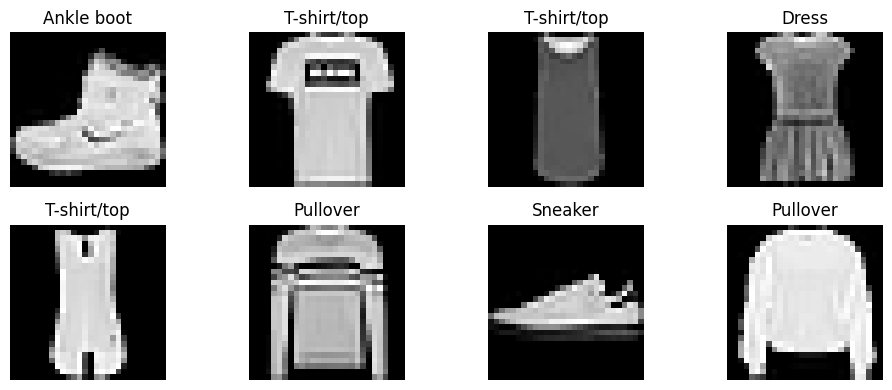

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

El dataset contiene imágenes pequeñas y centradas de prendas de vestir. Cada imagen pertenece a una de las 10 clases disponibles. Para esta lección, se simplificará el problema a una clasificación binaria.

## Preparación para clasificación binaria

In [4]:
# Convertir a problema binario: Sneaker (7) vs No Sneaker
y_train_bin = (y_train == 7).astype(int)
y_test_bin = (y_test == 7).astype(int)

print("Ejemplo etiquetas originales:", y_train[:10])
print("Ejemplo etiquetas binarias:", y_train_bin[:10])

Ejemplo etiquetas originales: [9 0 0 3 0 2 7 2 5 5]
Ejemplo etiquetas binarias: [0 0 0 0 0 0 1 0 0 0]


## Normalización de imágenes

In [5]:
# Normalizar pixeles entre 0 y 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Definición de la arquitectura de la red neuronal densa

Se construirá una red neuronal artificial simple compuesta por:
* una capa de transformación Flatten,
* dos capas densas ocultas,
* una capa de regularización Dropout,
* una capa de salida con activación sigmoid.

In [ ]:
# Modelo de red neuronal densa para clasificación binaria
model_l1 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu" ,),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_l1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

## Arquitectura implementada
* **Capa Flatten:** La capa Flatten transforma cada imagen de 28x28 píxeles en un vector de 784 valores. Esto permite que la red neuronal densa procese la imagen como entrada numérica lineal.

* **Capas Dense :** Las capas densas conectan cada neurona con todas las de la capa siguiente. En este caso:
    * la primera capa densa tiene 128 neuronas,
    * la segunda capa densa tiene 64 neuronas.
Estas capas permiten que el modelo aprenda patrones relevantes en los datos.

* **Pesos:** Los pesos son parámetros internos de la red que se ajustan durante el entrenamiento Representan la importancia de cada conexión entre neuronas.

* **Función de activación ReLU:** Se utiliza ReLU en las capas ocultas para introducir no linealidad en el modelo y mejorar su capacidad de aprendizaje.

* **Dropout :** La capa Dropout(0.3) apaga aleatoriamente un 30% de las neuronas durante el entrenamiento, reduciendo el riesgo de sobreajuste.

* **Capa de salida :** La capa final tiene una sola neurona con activación sigmoid, adecuada para clasificación binaria, ya que entrega una probabilidad entre 0 y 1.

## Compilación del modelo

In [8]:
model_l1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

* Adam: optimizador eficiente y ampliamente utilizado en deep learning.
* Binary Crossentropy: función de pérdida apropiada para problemas de clasificación binaria.
* Accuracy: métrica útil para medir la proporción de predicciones correctas.

## Entrenamiento del modelo

In [9]:
history_l1 = model_l1.fit(
    x_train, y_train_bin,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9739 - loss: 0.0666 - val_accuracy: 0.9843 - val_loss: 0.0431
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9832 - loss: 0.0446 - val_accuracy: 0.9839 - val_loss: 0.0406
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9853 - loss: 0.0401 - val_accuracy: 0.9871 - val_loss: 0.0358
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9862 - loss: 0.0361 - val_accuracy: 0.9869 - val_loss: 0.0369
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0340 - val_accuracy: 0.9826 - val_loss: 0.0574
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0329 - val_accuracy: 0.9872 - val_loss: 0.0373
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9883 - loss: 0.0308 - val_accuracy: 0.9874 - val_loss: 0.0423
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9886 - loss: 0.0291 - 

## Evaluación del modelo en conjunto de prueba

In [10]:
loss, acc = model_l1.evaluate(x_test, y_test_bin, verbose=0)
print(f"Pérdida en test: {loss:.4f}")
print(f"Accuracy en test: {acc:.4f}")

Pérdida en test: 0.0332
Accuracy en test: 0.9871


## Predicciones del modelo

In [11]:
y_pred_prob = model_l1.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Métricas de desempeño

In [12]:
print("Accuracy:", accuracy_score(y_test_bin, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test_bin, y_pred))

Accuracy: 0.9871

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9000
           1       0.95      0.92      0.93      1000

    accuracy                           0.99     10000
   macro avg       0.97      0.96      0.96     10000
weighted avg       0.99      0.99      0.99     10000



## Matriz de confusión

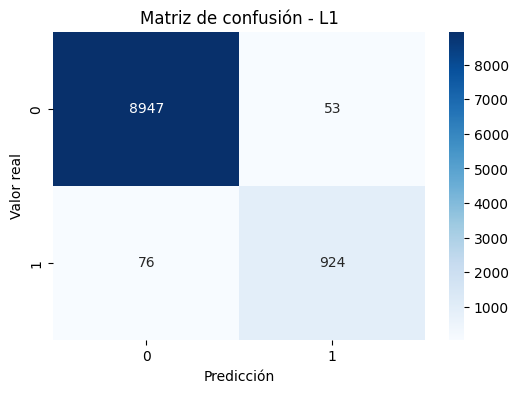

In [13]:
cm = confusion_matrix(y_test_bin, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - L1")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión muestra un alto desempeño del modelo, con la mayoría de las observaciones correctamente clasificadas en ambas clases. Se destacan 8947 verdaderos negativos y 924 verdaderos positivos, lo que indica una alta precisión general.

Los errores son bajos: 53 falsos positivos y 76 falsos negativos. Se observa que el modelo comete ligeramente más errores al no detectar sneakers reales que al clasificarlos incorrectamente, lo que sugiere un comportamiento algo conservador.

En conjunto, el modelo logra un buen equilibrio entre precisión y capacidad de detección, siendo adecuado para esta etapa inicial del proyecto.

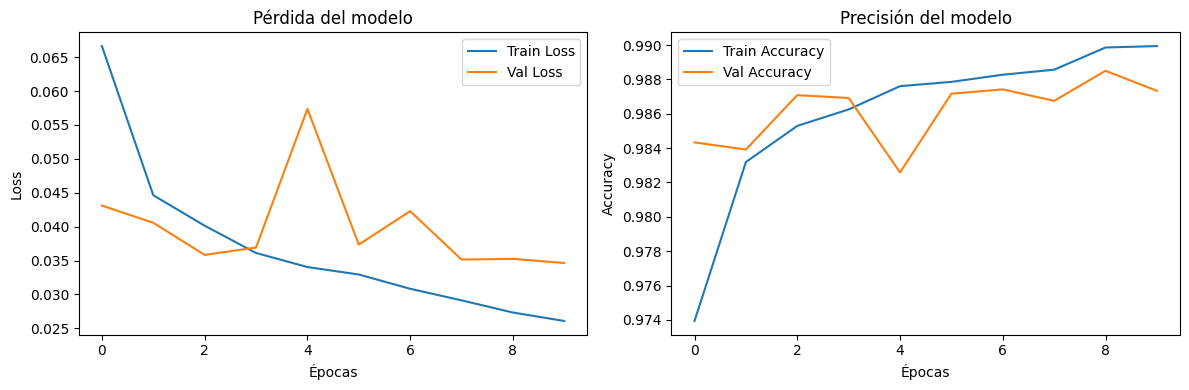

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_l1.history["loss"], label="Train Loss")
plt.plot(history_l1.history["val_loss"], label="Val Loss")
plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_l1.history["accuracy"], label="Train Accuracy")
plt.plot(history_l1.history["val_accuracy"], label="Val Accuracy")
plt.title("Precisión del modelo")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Conclusión
La implementación permitió construir una red neuronal artificial densa para resolver un problema de clasificación binaria sobre imágenes de ropa. La arquitectura definida fue adecuada al objetivo planteado, utilizando capas densas, activaciones no lineales, una función de pérdida adecuada y regularización mediante Dropout.

El modelo fue capaz de aprender patrones relevantes a partir de las imágenes y distinguir entre la clase “Sneaker” y el resto de las prendas. Además, se evaluó su rendimiento utilizando métricas cuantitativas y visualizaciones, lo que permitió analizar su capacidad predictiva y sus posibles errores.

Esta primera etapa sienta las bases para las siguientes lecciones del proyecto, donde se avanzará hacia una clasificación multiclase y posteriormente hacia el uso de redes convolutivas, más apropiadas para procesamiento de imágenes.